In [ ]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


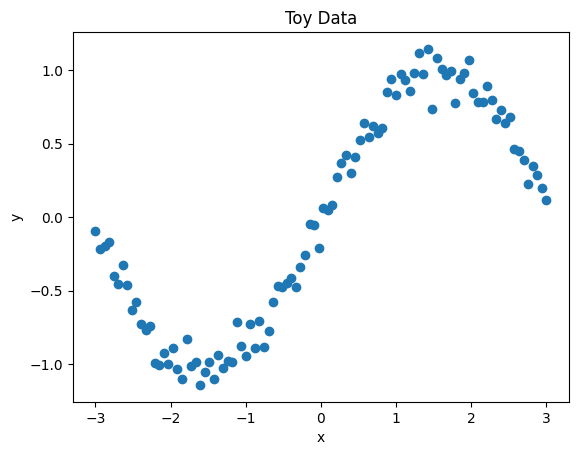

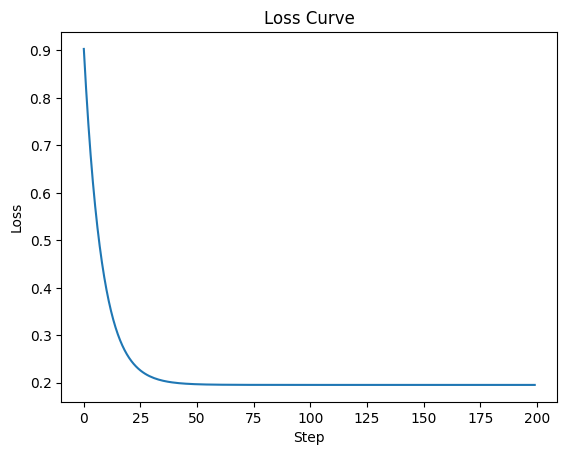

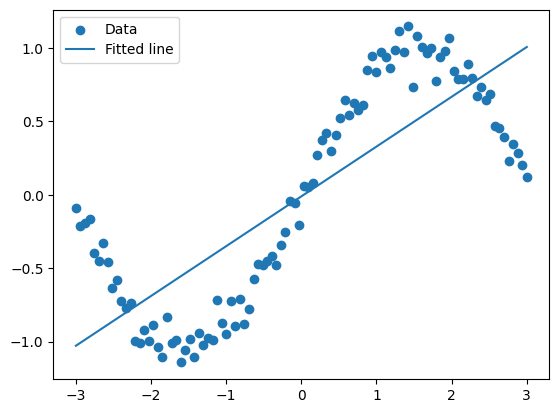

In [ ]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.randn(100) * 0.1

plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Toy Data")
plt.show()

# TODO: Initialise w and b to small random values.
w = np.random.randn()*0.1
b = np.random.randn()*0.1

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# y_hat = w*x + b
# loss = np.mean((y_hat - y) ** 2) 
# dw = np.mean(2 * (y_hat - y) * x)
# db = np.mean(2 * (y_hat - y)) 
# w -= lr * dw
# b -= lr * db


lr = 0.01
steps = 200
losses = []

for step in range(steps):
    y_hat = w*x + b
    loss = np.mean((y_hat - y) ** 2)
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))
    w -= lr * dw
    b -= lr * db

    losses.append(loss)


# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.

# Loss curve
plt.plot(losses)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.show()


# Data
y_pred = w*x + b

plt.scatter(x,y,label="Data")

plt.plot(x,y_pred,label="Fitted line")

plt.legend()
plt.show()

1. Derive dLoss/dw on paper and include a photo or the LaTeX in this cell — does it match the code? 

2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, and WHY can a single neuron never fit a sine wave, no matter how long you train?


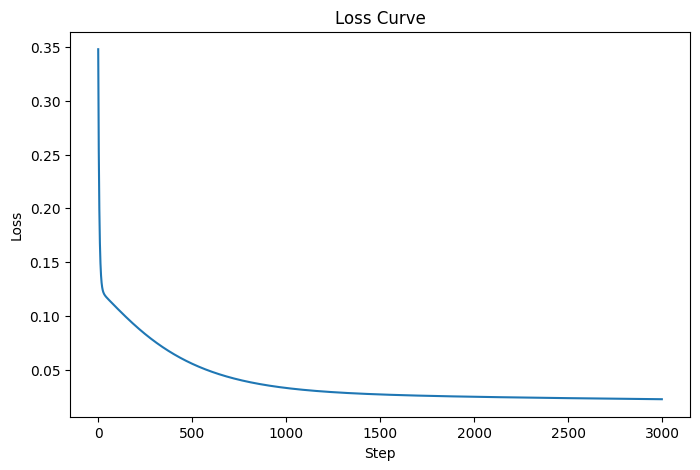

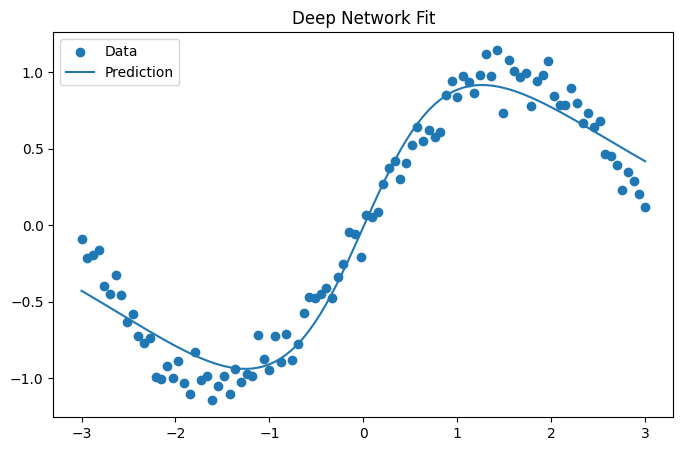

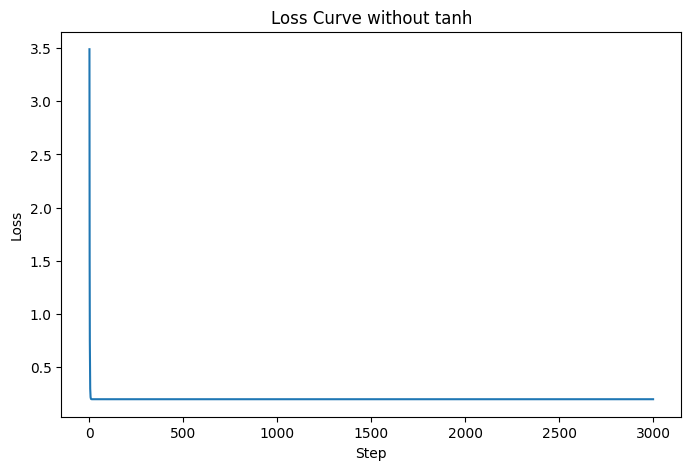

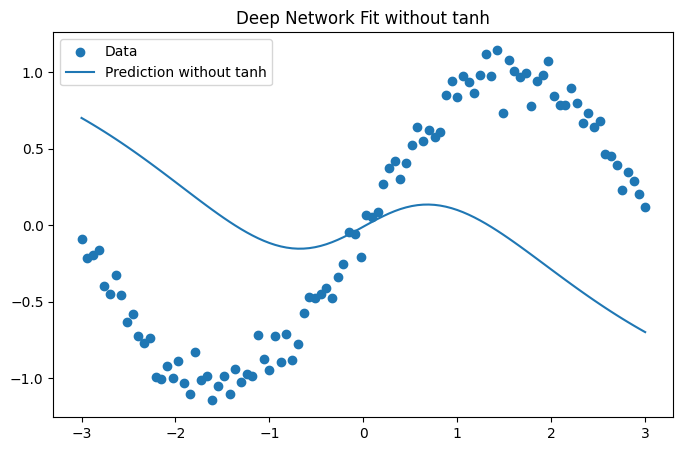

In [ ]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

x = x.reshape(-1, 1)
y = y.reshape(-1, 1)

W1 = np.random.randn(1, 8) * 0.5
b1 = np.zeros(8)

W2 = np.random.randn(8, 1) * 0.5
b2 = np.zeros(1)


# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# z1 = x @ W1 + b1
# h = np.tanh(z1)
# y_hat = h @ W2 + b2
# loss = np.mean((y_hat - y) ** 2)


# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# d_yhat = 2 * (y_hat - y) / len(y)
# dW2 = h.T @ d_yhat
# db2 = d_yhat.sum(axis=0)
# dh = d_yhat @ W2.T
# dz1 = dh * (1 - np.tanh(z1) ** 2)
# dW1 = x.T @ dz1
# db1 = dz1.sum(axis=0)


# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

lr = 0.01
steps = 3000
losses = []

for step in range(steps):
    # forward pass
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)

    # backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)


    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)


# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

# loss curve
plt.figure(figsize=(8,5))
plt.plot(losses)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.show()

# final fit
y_pred = np.tanh(x @ W1 + b1) @ W2 + b2

plt.figure(figsize=(8,5))

plt.scatter(x,y,label="Data")

plt.plot(x,y_pred,label="Prediction")

plt.legend()
plt.title("Deep Network Fit")
plt.show()


# Rerun with tanh removed
lr = 0.01
steps = 3000
losses = []

for step in range(steps):
    # forward pass
    z1 = x @ W1 + b1
    h = z1
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y) ** 2)

    # backward pass
    d_yhat = 2 * (y_hat - y) / len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh 
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)


    W1 -= lr * dW1
    b1 -= lr * db1

    W2 -= lr * dW2
    b2 -= lr * db2

    losses.append(loss)


# loss curve without tanh
plt.figure(figsize=(8,5))
plt.plot(losses)

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Loss Curve without tanh")

plt.show()

# final fit without tanh
y_pred = np.tanh(x @ W1 + b1) @ W2 + b2

plt.figure(figsize=(8,5))

plt.scatter(x,y,label="Data")

plt.plot(x,y_pred,label="Prediction without tanh")

plt.legend()
plt.title("Deep Network Fit without tanh")
plt.show()

/var/folders/6c/fnqvkk_11knfl7q7rryky8180000gq/T/ipykernel_3979/3363070294.py:21: RuntimeWarning: overflow encountered in square
  loss = np.mean((y_hat - y) ** 2)
/var/folders/6c/fnqvkk_11knfl7q7rryky8180000gq/T/ipykernel_3979/3363070294.py:28: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)


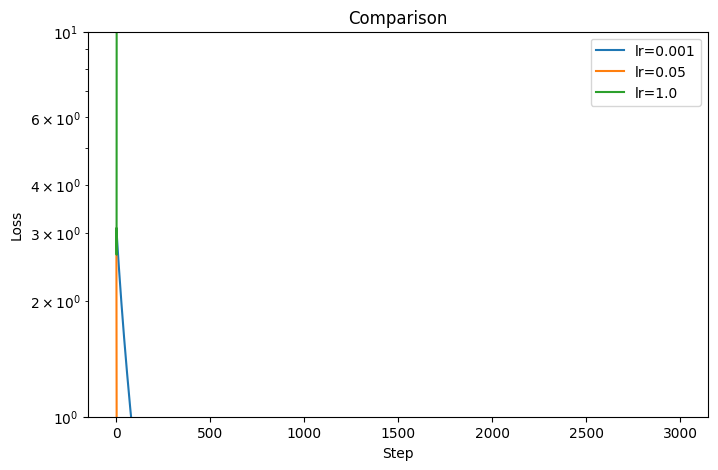

In [ ]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

def train_toy(lr, steps=3000):
    
    np.random.seed(RANDOM_STATE)

    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.zeros(8)

    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.zeros(1)

    losses = []

    for step in range(steps):
    # forward pass
        z1 = x @ W1 + b1
        h = np.tanh(z1)
        y_hat = h @ W2 + b2
        loss = np.mean((y_hat - y) ** 2)

    # backward pass
        d_yhat = 2 * (y_hat - y) / len(y)
        dW2 = h.T @ d_yhat
        db2 = d_yhat.sum(axis=0)
        dh = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)
        dW1 = x.T @ dz1
        db1 = dz1.sum(axis=0)


        W1 -= lr * dW1
        b1 -= lr * db1

        W2 -= lr * dW2
        b2 -= lr * db2

        losses.append(loss)

    return losses, W1, b1, W2, b2


# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).

loss1, W1_a, b1_a, W2_a, b2_a = train_toy(lr= 0.001)
loss2, W1_b, b1_b, W2_b, b2_b = train_toy(lr=0.05)
loss3, W1_c, b1_c, W2_c, b2_c = train_toy(lr=1.0)


# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend.

plt.figure(figsize=(8,5))

plt.plot(loss1, label="lr=0.001")
plt.plot(loss2, label="lr=0.05")
plt.plot(loss3, label="lr=1.0")

plt.yscale("log")

plt.xlabel("Step")
plt.ylabel("Loss")

plt.title("Comparison")

plt.legend()

plt.show()

In [ ]:
# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).
obesity = pd.read_csv("Obesity_level_prediction_dataset (2).csv")

# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.
binary_col = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_col:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

freq_order = {'no': 0, 'Sometimes': 1, 'Frequently': 2, 'Always': 3}
obesity['CAEC'] = obesity['CAEC'].map(freq_order)
obesity['CALC'] = obesity['CALC'].map(freq_order)

obesity = pd.get_dummies(obesity, columns=['Gender', 'MTRANS'], drop_first=True)

obesity['BMI'] = obesity['Weight'] / (obesity['Height'] ** 2)

from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).
X = obesity.drop(columns=['NObeyesdad'])
y = target_encoder.fit_transform(obesity['NObeyesdad'])

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.40, random_state=RANDOM_STATE, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp)


# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
import torch

X_train = torch.tensor(X_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

train_loader

In [25]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

# class FeedForwardNet(nn.Module):
#     def __init__(self, ...):
#         ...
#     def forward(self, x):
#         ...

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, droupout= 0.0):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_sizes[0]),
            nn.ReLU(),
            nn.Dropout(droupout),
            nn.Linear(hidden_sizes[0], hidden_sizes[1]),
            nn.ReLU(),
            nn.Dropout(droupout),
            nn.Linear(hidden_sizes[1], n_classes)
        )

    def forward(self, x):
        return self.network(x)

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_train.shape[1]
model = FeedForwardNet(input_dim=input_dim)
model = model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Trainable parameters:", num_params)

first_layer_params = input_dim * 64 + 64
print("First layer parameters:", first_layer_params)

FeedForwardNet(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.0, inplace=False)
    (6): Linear(in_features=32, out_features=7, bias=True)
  )
)
Trainable parameters: 3655
First layer parameters: 1344


Epoch 1/50 Train Loss: 1.8461 Val Loss: 1.7313 Train Acc: 0.3381 Val Acc: 0.4739
Epoch 2/50 Train Loss: 1.5186 Val Loss: 1.3550 Train Acc: 0.5600 Val Acc: 0.5664
Epoch 3/50 Train Loss: 1.1351 Val Loss: 1.0266 Train Acc: 0.6193 Val Acc: 0.6706
Epoch 4/50 Train Loss: 0.8583 Val Loss: 0.8243 Train Acc: 0.7180 Val Acc: 0.7630
Epoch 5/50 Train Loss: 0.6745 Val Loss: 0.6972 Train Acc: 0.7875 Val Acc: 0.7938
Epoch 6/50 Train Loss: 0.5477 Val Loss: 0.6158 Train Acc: 0.8341 Val Acc: 0.7938
Epoch 7/50 Train Loss: 0.4588 Val Loss: 0.5471 Train Acc: 0.8523 Val Acc: 0.8460
Epoch 8/50 Train Loss: 0.3891 Val Loss: 0.4968 Train Acc: 0.8799 Val Acc: 0.8602
Epoch 9/50 Train Loss: 0.3314 Val Loss: 0.4652 Train Acc: 0.9013 Val Acc: 0.8791
Epoch 10/50 Train Loss: 0.2889 Val Loss: 0.4595 Train Acc: 0.9139 Val Acc: 0.8720
Epoch 11/50 Train Loss: 0.2597 Val Loss: 0.4217 Train Acc: 0.9305 Val Acc: 0.8815
Epoch 12/50 Train Loss: 0.2228 Val Loss: 0.4138 Train Acc: 0.9368 Val Acc: 0.8815
Epoch 13/50 Train Loss: 0

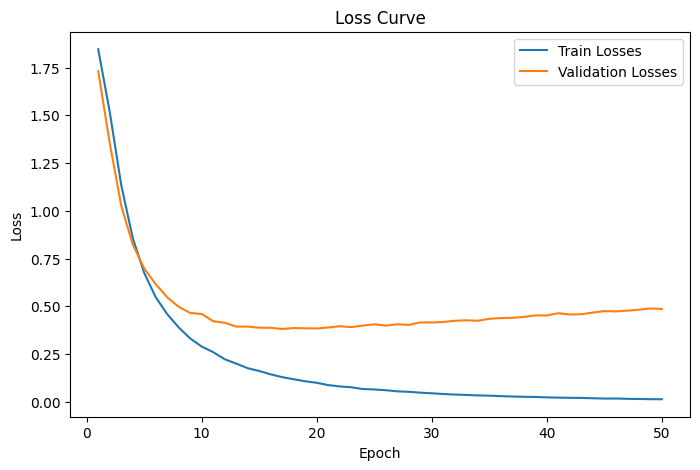

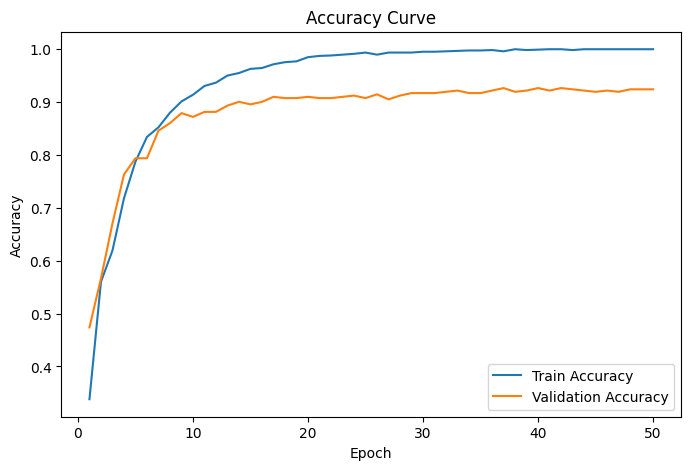

In [26]:
# TODO: criterion = nn.CrossEntropyLoss()
#       optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# TODO: Train for at least 50 epochs. Each epoch:
#   1. model.train(); for xb, yb in train_loader:
#        optimizer.zero_grad()
#        logits = model(xb.to(DEVICE))
#        loss = criterion(logits, yb.to(DEVICE))
#        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
#        optimizer.step()         # <- the update rule you wrote in Part 1.1
#   2. model.eval() + torch.no_grad(): compute loss AND accuracy on train and validation sets
#   3. Append everything to history lists; print a one-line summary per epoch.


train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_val_acc = 0

for epoch in range(50):
    model.train()

    running_loss = 0
    correct = 0
    total = 0


    for xb, yb in train_loader:

        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()


        running_loss += loss.item()
        prediction = torch.argmax(logits, dim=1)

        correct += (prediction == yb).sum().item()
        total += yb.size(0)

    train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total



    model.eval()

    val_loss = 0
    val_correct = 0
    val_total = 0


    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)

            val_loss += loss.item()
            predictions = torch.argmax(logits, dim=1)

            val_correct += (predictions == yb).sum().item()
            val_total += yb.size(0)

    val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    print(
        f"Epoch {epoch+1}/50 "
        f"Train Loss: {train_loss:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )

# TODO: Save the best model (highest validation accuracy):
#   torch.save(model.state_dict(), "ffn_best.pt")

    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), "ffn_best.pt")


# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(8,5))
plt.plot(epochs, train_losses, label="Train Losses")
plt.plot(epochs, val_losses, label="Validation Losses")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.show()


plt.figure(figsize=(8,5))
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

Epoch 1/50 Train Loss: 1.9069 Val Loss: 1.8427 Train Acc: 0.2196 Val Acc: 0.2844
Epoch 2/50 Train Loss: 1.8000 Val Loss: 1.7428 Train Acc: 0.3412 Val Acc: 0.3720
Epoch 3/50 Train Loss: 1.7009 Val Loss: 1.6423 Train Acc: 0.3673 Val Acc: 0.4028
Epoch 4/50 Train Loss: 1.6036 Val Loss: 1.5490 Train Acc: 0.3965 Val Acc: 0.4265
Epoch 5/50 Train Loss: 1.5134 Val Loss: 1.4572 Train Acc: 0.4313 Val Acc: 0.4668
Epoch 6/50 Train Loss: 1.4222 Val Loss: 1.3684 Train Acc: 0.4739 Val Acc: 0.5047
Epoch 7/50 Train Loss: 1.3330 Val Loss: 1.2891 Train Acc: 0.5095 Val Acc: 0.5403
Epoch 8/50 Train Loss: 1.2572 Val Loss: 1.2225 Train Acc: 0.5387 Val Acc: 0.5427
Epoch 9/50 Train Loss: 1.1906 Val Loss: 1.1662 Train Acc: 0.5577 Val Acc: 0.5592
Epoch 10/50 Train Loss: 1.1353 Val Loss: 1.1200 Train Acc: 0.5624 Val Acc: 0.5735
Epoch 11/50 Train Loss: 1.0836 Val Loss: 1.0802 Train Acc: 0.5758 Val Acc: 0.5900
Epoch 12/50 Train Loss: 1.0445 Val Loss: 1.0446 Train Acc: 0.5845 Val Acc: 0.5995
Epoch 13/50 Train Loss: 1

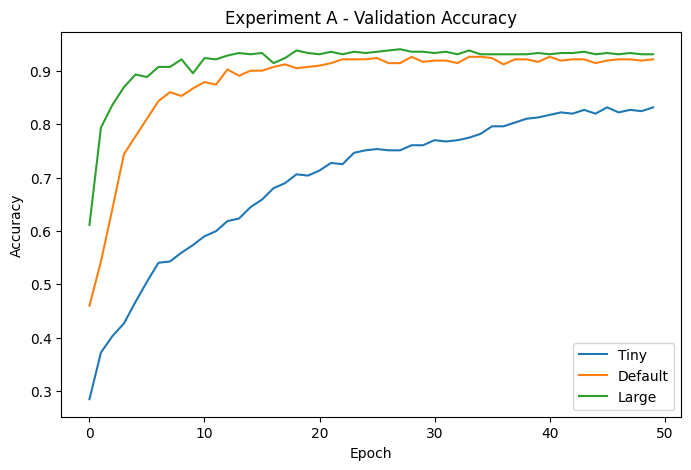

Epoch 1/50 Train Loss: 1.9491 Val Loss: 1.9411 Train Acc: 0.2243 Val Acc: 0.2464
Epoch 2/50 Train Loss: 1.9286 Val Loss: 1.9207 Train Acc: 0.2725 Val Acc: 0.2891
Epoch 3/50 Train Loss: 1.9065 Val Loss: 1.8990 Train Acc: 0.3167 Val Acc: 0.3436
Epoch 4/50 Train Loss: 1.8832 Val Loss: 1.8745 Train Acc: 0.3657 Val Acc: 0.3815
Epoch 5/50 Train Loss: 1.8565 Val Loss: 1.8467 Train Acc: 0.4005 Val Acc: 0.4123
Epoch 6/50 Train Loss: 1.8257 Val Loss: 1.8152 Train Acc: 0.4289 Val Acc: 0.4455
Epoch 7/50 Train Loss: 1.7915 Val Loss: 1.7790 Train Acc: 0.4463 Val Acc: 0.4645
Epoch 8/50 Train Loss: 1.7518 Val Loss: 1.7397 Train Acc: 0.4660 Val Acc: 0.4882
Epoch 9/50 Train Loss: 1.7101 Val Loss: 1.6954 Train Acc: 0.4834 Val Acc: 0.4905
Epoch 10/50 Train Loss: 1.6641 Val Loss: 1.6477 Train Acc: 0.4953 Val Acc: 0.4858
Epoch 11/50 Train Loss: 1.6123 Val Loss: 1.5989 Train Acc: 0.5024 Val Acc: 0.4953
Epoch 12/50 Train Loss: 1.5611 Val Loss: 1.5504 Train Acc: 0.5111 Val Acc: 0.5071
Epoch 13/50 Train Loss: 1

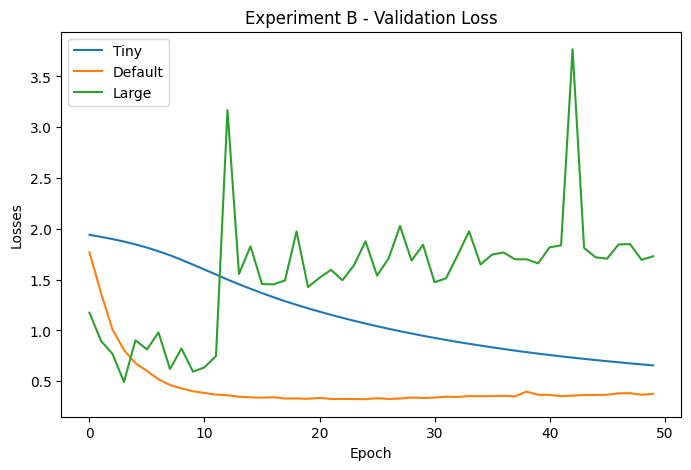

Epoch 1/50 Train Loss: 1.5901 Val Loss: 1.0413 Train Acc: 0.5103 Val Acc: 0.6754
Epoch 2/50 Train Loss: 0.6814 Val Loss: 0.5766 Train Acc: 0.7883 Val Acc: 0.8104
Epoch 3/50 Train Loss: 0.3566 Val Loss: 0.4960 Train Acc: 0.8934 Val Acc: 0.8436
Epoch 4/50 Train Loss: 0.2359 Val Loss: 0.4019 Train Acc: 0.9265 Val Acc: 0.9005
Epoch 5/50 Train Loss: 0.1571 Val Loss: 0.3909 Train Acc: 0.9645 Val Acc: 0.9076
Epoch 6/50 Train Loss: 0.1406 Val Loss: 0.4368 Train Acc: 0.9581 Val Acc: 0.9123
Epoch 7/50 Train Loss: 0.0904 Val Loss: 0.4436 Train Acc: 0.9763 Val Acc: 0.9100
Epoch 8/50 Train Loss: 0.0640 Val Loss: 0.4543 Train Acc: 0.9889 Val Acc: 0.9028
Epoch 9/50 Train Loss: 0.0537 Val Loss: 0.4924 Train Acc: 0.9905 Val Acc: 0.9171
Epoch 10/50 Train Loss: 0.0458 Val Loss: 0.5404 Train Acc: 0.9897 Val Acc: 0.9005
Epoch 11/50 Train Loss: 0.0390 Val Loss: 0.4962 Train Acc: 0.9929 Val Acc: 0.9123
Epoch 12/50 Train Loss: 0.0268 Val Loss: 0.4991 Train Acc: 0.9968 Val Acc: 0.9171
Epoch 13/50 Train Loss: 0

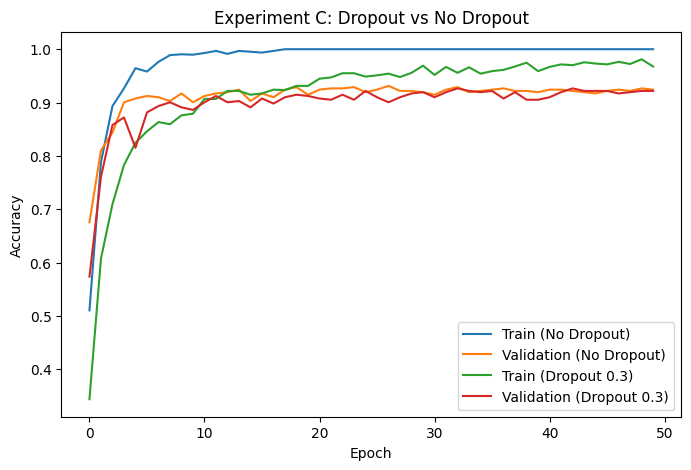

In [27]:
# Wrap your Part 2.3 loop in a function first:
#   def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):
#       ... returns history dict ...

def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0, save_path="ffn_best.pt"):

    model = FeedForwardNet(input_dim=X_train.shape[1], hidden_sizes=hidden_sizes, dropout=dropout)
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    batch_size = batch_size


    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    best_val_acc = 0

    for epoch in range(epochs):
        model.train()

        running_loss = 0
        correct = 0
        total = 0


        for xb, yb in train_loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
        
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()


            running_loss += loss.item()
            prediction = torch.argmax(logits, dim=1)

            correct += (prediction == yb).sum().item()
            total += yb.size(0)

        train_loss = running_loss / len(train_loader)
        train_accuracy = correct / total



        model.eval()

        val_loss = 0
        val_correct = 0
        val_total = 0


        with torch.no_grad():

            for xb, yb in val_loader:

                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(xb)
                loss = criterion(logits, yb)

                val_loss += loss.item()
                predictions = torch.argmax(logits, dim=1)

                val_correct += (predictions == yb).sum().item()
                val_total += yb.size(0)

        val_loss = val_loss / len(val_loader)
        val_accuracy = val_correct / val_total
    

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)


        print(
            f"Epoch {epoch+1}/{epochs} "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"Train Acc: {train_accuracy:.4f} "
            f"Val Acc: {val_accuracy:.4f}"
        )

        if val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            torch.save(model.state_dict(), save_path)


    history_dict = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "train_accuracies": train_accuracies,
    "val_accuracies": val_accuracies
    }
    
    return history_dict


class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64,32), n_classes=7, dropout=0.0):
        super().__init__()

        layers = []

        prev_dim = input_dim

        for hidden in hidden_sizes:
            layers.append(nn.Linear(prev_dim, hidden))
            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_dim = hidden

        layers.append(nn.Linear(prev_dim, n_classes))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)
    

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

tiny = run_experiment(hidden_sizes=(8,), save_path="ffn_best_capacity_tiny.pt")
default = run_experiment(hidden_sizes=(64,32), save_path="ffn_best_capacity_default.pt")
large = run_experiment(hidden_sizes=(256, 128, 64), save_path="ffn_best_capacity_large.pt")

plt.figure(figsize=(8,5))

plt.plot(tiny['val_accuracies'], label = 'Tiny')
plt.plot(default['val_accuracies'], label = 'Default')
plt.plot(large['val_accuracies'], label = 'Large')


plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Experiment A - Validation Accuracy")

plt.legend()

plt.show()


# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

tiny = run_experiment(lr=1e-4, save_path="ffn_best_lr_1e-4.pt")
default = run_experiment(lr=1e-3, save_path="ffn_best_lr_1e-3.pt")
large = run_experiment(lr=1e-1, save_path="ffn_best_lr_1e-1.pt")

plt.figure(figsize=(8,5))

plt.plot(tiny['val_losses'], label = 'Tiny')
plt.plot(default['val_losses'], label = 'Default')
plt.plot(large['val_losses'], label = 'Large')


plt.xlabel("Epoch")
plt.ylabel("Losses")

plt.title("Experiment B - Validation Loss")

plt.legend()

plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

no_dropout = run_experiment(
    hidden_sizes=(256,128,64),
    dropout=0.0,
    save_path="ffn_best_no_dropout.pt"
)

dropout_history = run_experiment(
    hidden_sizes=(256,128,64),
    dropout=0.3,
    save_path="ffn_best_dropout.pt"
)

plt.figure(figsize=(8,5))

plt.plot(no_dropout["train_accuracies"], label="Train (No Dropout)")
plt.plot(no_dropout["val_accuracies"], label="Validation (No Dropout)")

plt.plot(dropout_history["train_accuracies"], label="Train (Dropout 0.3)")
plt.plot(dropout_history["val_accuracies"], label="Validation (Dropout 0.3)")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment C: Dropout vs No Dropout")

plt.legend()

plt.show()